In [5]:
import pandas as pd
df=pd.read_csv('athlete_events.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


 Get duplicates across all columns

In [7]:
duplicates=df.duplicated()
print(duplicates)

0         False
1         False
2         False
3         False
4         False
          ...  
271111    False
271112    False
271113    False
271114    False
271115    False
Length: 271116, dtype: bool


 Get duplicate rows

In [9]:
df[duplicates]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
1252,704,Dsir Antoine Acket,M,27.0,NaN,NaN,Belgium,BEL,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN
4282,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And ...",NaN
4283,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And ...",NaN
4862,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Designs F...",NaN
4864,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architect...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269994,135072,Anna Katrina Zinkeisen (-Heseltine),F,46.0,NaN,NaN,Great Britain,GBR,1948 Summer,1948,Summer,London,Art Competitions,"Art Competitions Mixed Painting, Paintings",NaN
269995,135072,Anna Katrina Zinkeisen (-Heseltine),F,46.0,NaN,NaN,Great Britain,GBR,1948 Summer,1948,Summer,London,Art Competitions,"Art Competitions Mixed Painting, Paintings",NaN
269997,135072,Anna Katrina Zinkeisen (-Heseltine),F,46.0,NaN,NaN,Great Britain,GBR,1948 Summer,1948,Summer,London,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN
269999,135073,Doris Clare Zinkeisen (-Johnstone),F,49.0,NaN,NaN,Great Britain,GBR,1948 Summer,1948,Summer,London,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN


Drop duplicates

In [10]:
df.drop_duplicates(inplace=True)

In [19]:


valid_medal = {"Gold", "Bronze", "Silver"}

categories = {
    "Medal": valid_medal
}



Finding inconsistent categories

In [20]:
observed = set(df["Medal"].astype(str).str.strip().str.title().unique())

inconsistent_categories = observed - categories["Medal"]
print(inconsistent_categories)


{'Nan'}


In [21]:
df['Medal'] = df['Medal'].fillna("No medal")

In [22]:
df['Season'].unique()

array(['Summer', 'Winter'], dtype=object)

Replacing  missing values in Height	Weight with the median

In [23]:
Height_Median=df['Height'].median()
Weight_Median=df['Weight'].median()
df=df.fillna({'Height':Height_Median,'Weight':Weight_Median})
df.head(10)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
2,3,Gunnar Nielsen Aaby,M,24.0,175.0,70.0,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No medal
3,4,Edgar Lindenau Aabye,M,34.0,175.0,70.0,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No medal
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",No medal
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,No medal
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",No medal
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,No medal
9,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",No medal


In [60]:
df['IMC'] = df['Weight'] / ((df['Height'] / 100) ** 2)
# Remplacer Height/Weight par IMC uniquement
df = df.drop(columns=['Height', 'Weight'])
# Déplacer IMC à la position 4
imc_col = df.pop('IMC')
df.insert(4, 'IMC', imc_col)
df.head()

KeyError: 'Weight'

In [31]:
# Déplacer IMC en position 4
imc_col = df.pop('IMC')      # retire la colonne IMC
df.insert(4, 'IMC', imc_col)

Drop Games and Team column

In [59]:

if 'Games' in df.columns:
    df = df.drop(columns=['Games'])
if 'Team' in df.columns:
    df = df.drop(columns=['Team'])

In [53]:
print(df.columns.tolist())

['ID', 'Name', 'Sex', 'Age', 'IMC', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']


sort the dataframe 

In [55]:
df=df.sort_values(by=['Age','Year'],ascending=[True,True],na_position='first')
df=df.reset_index(drop=True)

In [35]:
df.head()

,ID,Name,Sex,Age,IMC,Team,NOC,Year,Season,City,Sport,Event,Medal
0,1724,Aristidis Akratopoulos,M,NaN,22.857143,Greece,GRE,1896,Summer,Athina,Tennis,Tennis Men's Singles,No medal
1,1724,Aristidis Akratopoulos,M,NaN,22.857143,Greece-3,GRE,1896,Summer,Athina,Tennis,Tennis Men's Doubles,No medal
2,1725,"Konstantinos ""Kostas"" Akratopoulos",M,NaN,22.857143,Greece,GRE,1896,Summer,Athina,Tennis,Tennis Men's Singles,No medal
3,1725,"Konstantinos ""Kostas"" Akratopoulos",M,NaN,22.857143,Greece-3,GRE,1896,Summer,Athina,Tennis,Tennis Men's Doubles,No medal
4,4113,Anastasios Andreou,M,NaN,22.857143,Greece,GRE,1896,Summer,Athina,Athletics,Athletics Men's 110 metres Hurdles,No medal


Drop missing Values

In [56]:
df=df.dropna(subset=['Age'])
df.head()

,ID,Name,Sex,Age,IMC,NOC,Year,Season,City,Sport,Event,Medal
0,71691,Dimitrios Loundras,M,10.0,22.857143,GRE,1896,Summer,Athina,Gymnastics,"Gymnastics Men's Parallel Bars, Teams",Bronze
1,47618,"Sonja Henie (-Topping, -Gardiner, -Onstad)",F,11.0,18.730489,NOR,1924,Winter,Chamonix,Figure Skating,Figure Skating Women's Singles,No medal
2,40129,Luigina Giavotti,F,11.0,22.857143,ITA,1928,Summer,Amsterdam,Gymnastics,Gymnastics Women's Team All-Around,Silver
3,22411,Magdalena Cecilia Colledge,F,11.0,30.297784,GBR,1932,Winter,Lake Placid,Figure Skating,Figure Skating Women's Singles,No medal
4,118925,Megan Olwen Devenish Taylor (-Mandeville-Ellis),F,11.0,28.398718,GBR,1932,Winter,Lake Placid,Figure Skating,Figure Skating Women's Singles,No medal


In [41]:
import matplotlib.pyplot as plt

Percentage of medals by Sex category

In [39]:
medal_df=df[df['Medal'].isin(['Gold','Silver','Bronze'])]
counts=medal_df['Sex'].value_counts()
percentages=(counts/counts.sum())*100

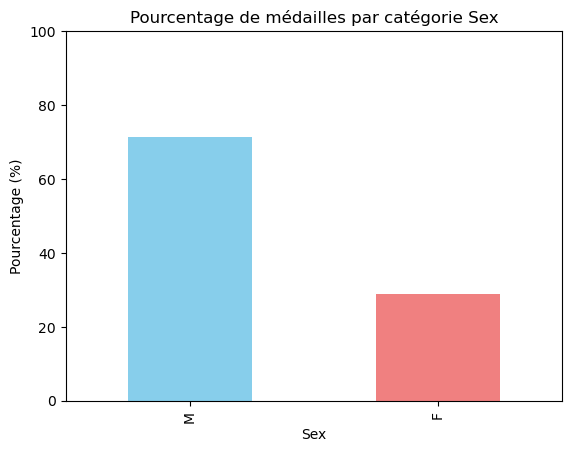

In [42]:
percentages.plot(kind='bar',color=['skyblue','lightcoral'])
plt.title("Pourcentage de médailles par catégorie Sex")
plt.xlabel("Sex")
plt.ylabel("Pourcentage (%)")
plt.ylim(0,100)
plt.show()

In [43]:
import seaborn as sns

Distribution of BMI by type of medal

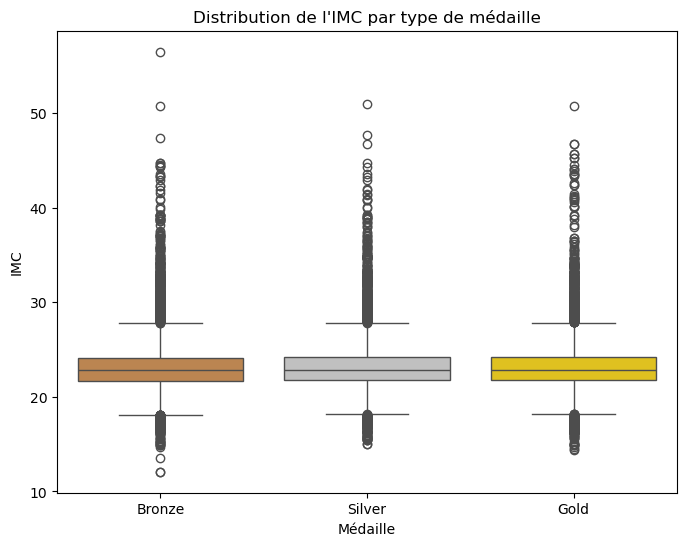

In [47]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=medal_df,
    x='Medal',
    y='IMC',
    hue='Medal',                     
    palette={'Gold': 'gold', 'Silver': 'silver', 'Bronze': 'peru'},
    legend=False                     
)

plt.title("Distribution de l'IMC par type de médaille")
plt.xlabel("Médaille")
plt.ylabel("IMC")
plt.show()



 Nombre de médailles par équipe (Team)

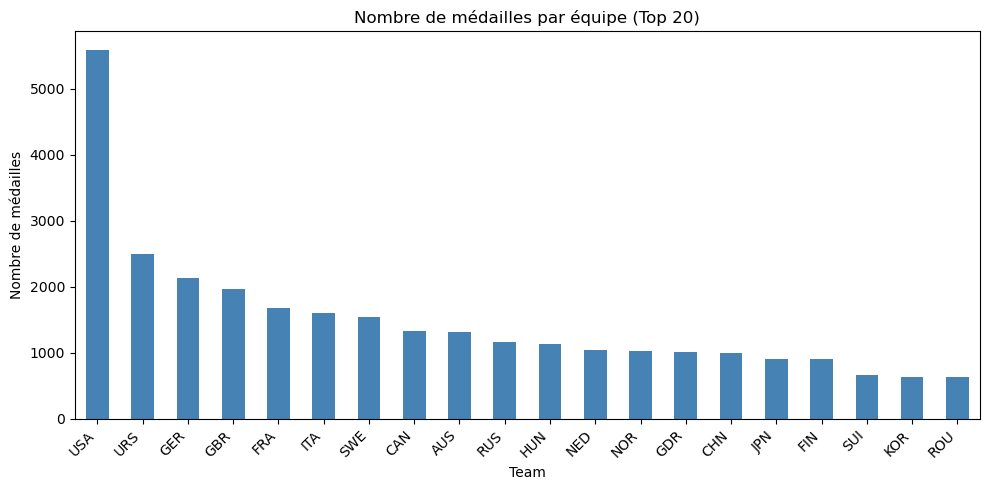

In [57]:
#compter les medailles par Team
counts = medal_df.groupby('NOC')['Medal'].count().sort_values(ascending=False)
#Afficher le top N
N=20
top_counts=counts.head(N)
plt.figure(figsize=(10,5))
top_counts.plot(kind='bar',color='steelblue')

plt.title(f"Nombre de médailles par équipe (Top {N})")
plt.xlabel("Team")
plt.ylabel("Nombre de médailles")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In [58]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260416 entries, 0 to 260415
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      260416 non-null  int64  
 1   Name    260416 non-null  object 
 2   Sex     260416 non-null  object 
 3   Age     260416 non-null  float64
 4   IMC     260416 non-null  float64
 5   NOC     260416 non-null  object 
 6   Year    260416 non-null  int64  
 7   Season  260416 non-null  object 
 8   City    260416 non-null  object 
 9   Sport   260416 non-null  object 
 10  Event   260416 non-null  object 
 11  Medal   260416 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 23.8+ MB


,ID,Age,IMC,Year
count,260416.000000,260416.000000,260416.000000,260416.000000
mean,68302.983645,25.454776,22.812466,1980.328820
std,39001.549258,6.163869,2.638582,28.496924
min,1.000000,10.000000,8.360954,1896.000000
25%,34761.750000,21.000000,21.357796,1964.000000
50%,68224.000000,24.000000,22.857143,1988.000000
75%,102120.250000,28.000000,23.766410,2004.000000
max,135571.000000,97.000000,63.901580,2016.000000


ML model: predict “medal or not”

In [61]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


In [63]:
df['HasMedal']=(df['Medal'].isin(['Gold','Silver','Bronze'])).astype(int)
X=df[['Age','IMC','Sex','Sport','NOC']]
y=df['HasMedal']
#numeric features
numcat=['Age','IMC']
#categorical features
catcat=['Sex','Sport','NOC']


preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), catcat),
    ('num', 'passthrough', numcat)
])

model = Pipeline([
    ('prep', preprocess),
    ('logReg', LogisticRegression(max_iter=1000))
])
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model.fit(X_train,y_train)
print("Accuracy :",model.score(X_test,y_test))



Accuracy : 0.8552338530066815
